In [17]:
from core import DataFrame
from io_module import read_csv_chunks
from processing import ChunkProcessor
import matplotlib.pyplot as plt

df = DataFrame.from_csv("../data/spotify_songs.csv")

# SQL

## The Graph of Average Track Population by selected var 

In [18]:
def plot_group_popularity(df, var):
    grouped_var = df.groupby(var)
    var_stats = grouped_var.aggregate({
        'track_popularity': 'mean',
        'track_id': 'count'
    })
    
    vars = var_stats[var]
    avg_popularity = var_stats['track_popularity_mean']
    song_counts = var_stats['track_id_count']
    
    plt.style.use('ggplot')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.bar(vars, avg_popularity, color='skyblue', edgecolor='black')
    ax1.set_title('Average Track Popularity by Genre')
    ax1.set_xlabel('Genre')
    ax1.set_ylabel('Avg Popularity')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylim(0, 100)
    
    ax2.bar(vars, song_counts, color='salmon', edgecolor='black')
    ax2.set_title('Number of Songs by Genre')
    ax2.set_xlabel('Genre')
    ax2.set_ylabel('Count')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

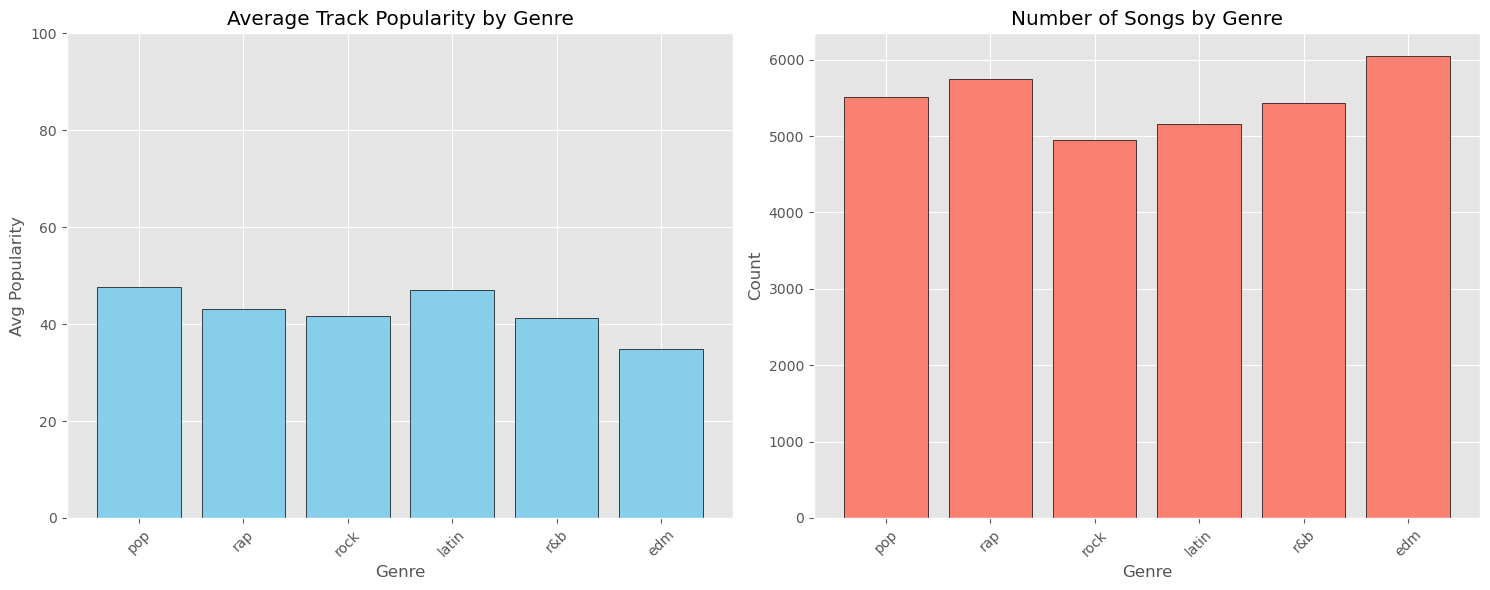

In [19]:
plot_group_popularity(df, 'playlist_genre')

## The trend of popularity with var

In [20]:
def plot_trend_with_var(df, var):
    plt.figure(figsize=(10, 6))
    plt.plot(df[var], df['track_popularity'], 'o', alpha=0.1, color='blue')
    plt.title(f'Track Popularity vs {var}')
    plt.xlabel(var)
    plt.ylabel('Track Popularity')
    plt.grid()
    plt.show()

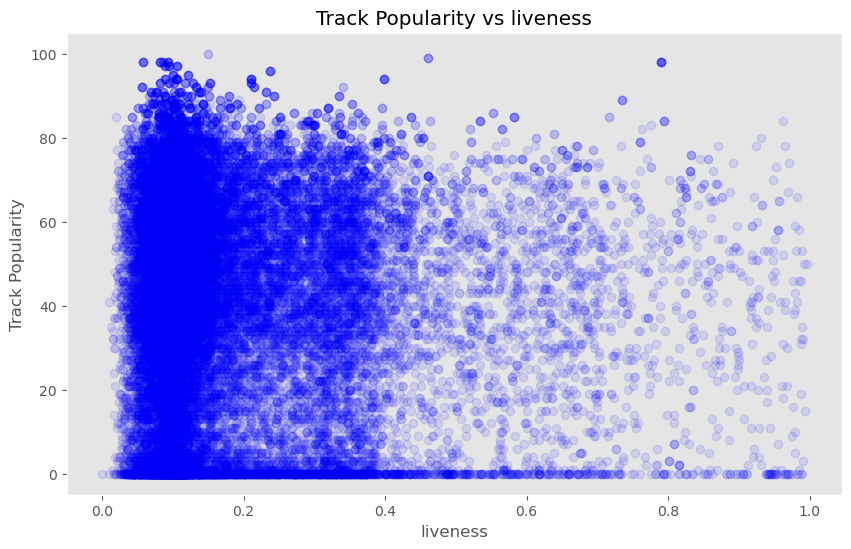

In [21]:
plot_trend_with_var(df, 'liveness')

## Top N of song or singer

In [22]:
def most_popular_singers(df, top_n=5):
    grouped_artist = df.groupby('track_artist')
    artist_stats = grouped_artist.aggregate({
        'track_popularity': 'mean',
        'track_id': 'count'
    })
    
    artists = artist_stats['track_artist']
    avg_popularity = artist_stats['track_popularity_mean']
    song_counts = artist_stats['track_id_count']
    
    combined_data = list(zip(artists, avg_popularity, song_counts))
    combined_data.sort(key=lambda x: x[1] if x[1] is not None else 0, reverse=True)
    
    print(f"=== The most popular {top_n} singers ===")
    for i in range(top_n):
        artist, pop, count = combined_data[i]
        print(f"No.{i+1}: {artist} (Popularity: {pop:.1f}, Number of Songs: {count})")

In [23]:
most_popular_singers(df, top_n=5)

=== The most popular 5 singers ===
No.1: Trevor Daniel (Popularity: 97.0, Number of Songs: 6)
No.2: Y2K (Popularity: 91.0, Number of Songs: 7)
No.3: Don Toliver (Popularity: 90.7, Number of Songs: 7)
No.4: Roddy Ricch (Popularity: 88.2, Number of Songs: 19)
No.5: DaBaby (Popularity: 87.9, Number of Songs: 14)


## Processing chunk

In [24]:
reader = read_csv_chunks("../data/spotify_songs.csv", chunk_size=1000)
filtered = ChunkProcessor.filter_chunks(
    reader,
    lambda row: row['track_popularity'] > 60
)

for chunk in filtered:
    print(chunk)

track_id             | track_name           | track_artist   | track_popularity | track_album_id       | track_album_name     | track_album_release_date | playlist_name | playlist_id          | playlist_genre | playlist_subgenre | danceability | energy | key | loudness | mode | speechiness | acousticness | instrumentalness | liveness | valence | tempo   | duration_ms
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
6f807x0ima9a1j3VP... | I Don't Care (wit... | Ed Sheeran     | 66               | 2oCs0DGTsRO98Gh5Z... | I Don't Care (wit... | 2019-06-14           | Pop Remix     | 37i9dQZF1DXcZDD7c... | pop            | dance pop         | 0.748        | 0.916  | 6   | -2.

In [25]:
reader = read_csv_chunks("../data/spotify_songs.csv", chunk_size=1000)

group_cols = "playlist_genre"
operations = {
    "track_popularity": "mean", 
    "track_id": "count"         
}

result_df = ChunkProcessor.aggregate_chunks(
    chunk_reader=reader,
    group_by_cols=group_cols,
    agg_dict=operations
)

print(result_df)

playlist_genre | track_popularity_mean | track_id_count
-------------------------------------------------------
pop            | 46.582925049309665   | 5507          
rap            | 44.66184646370474    | 5746          
rock           | 39.55865807018925    | 4951          
latin          | 46.269218350340374   | 5155          
r&b            | 41.73438912366621    | 5431          
edm            | 35.88185222660493    | 6043          

Shape: (6 rows, 3 columns)


---

# NoSQL

In [26]:
from nosql_module import *
print("✅ 成功匯入 nosql_module.py！")

✅ 成功匯入 nosql_module.py！


In [27]:
data = load_json("spotify_reviews.json")
print(f"✅ 已載入 {len(data)} 筆資料")
print("第一筆資料：", data[0])

✅ 已載入 500 筆資料
第一筆資料： {'user_id': 1, 'track_name': 'Senorita', 'rating': 4, 'review': 'The chorus makes the song feel Fantastic.', 'play_count': 158}


In [28]:
filtered = filter_json(data, "rating", ">", 4)
print(f"⭐ 高評分歌曲數量：{len(filtered)}")
print(filtered[:3])

⭐ 高評分歌曲數量：111
[{'user_id': 5, 'track_name': 'Levitating', 'rating': 5, 'review': 'Feels so Calm because of the melody.', 'play_count': 58}, {'user_id': 6, 'track_name': 'Circles', 'rating': 5, 'review': 'I really enjoyed the Amazing vocals.', 'play_count': 150}, {'user_id': 8, 'track_name': 'Someone You Loved', 'rating': 5, 'review': 'Feels so Decent because of the rhythm.', 'play_count': 64}]


In [29]:
projected = project_json(filtered, ["track_name", "rating"])
print("🎵 投影欄位（前5筆）：", projected[:5])

🎵 投影欄位（前5筆）： [{'track_name': 'Levitating', 'rating': 5}, {'track_name': 'Circles', 'rating': 5}, {'track_name': 'Someone You Loved', 'rating': 5}, {'track_name': 'Blinding Lights', 'rating': 5}, {'track_name': 'Someone You Loved', 'rating': 5}]


In [30]:
grouped = group_and_aggregate(data, "track_name", "rating", "avg")
print("📊 各曲目平均評分：")
for k, v in grouped.items():
    print(f"{k}: {v:.2f}")

📊 各曲目平均評分：
Senorita: 3.27
Happier: 3.03
Circles: 3.07
Believer: 2.45
Levitating: 2.94
Someone You Loved: 3.32
Blinding Lights: 3.29
Sunflower: 2.61
Stay: 3.32
Memories: 3.00
Shape of You: 2.88
Rockstar: 3.19
Dance Monkey: 3.20
Perfect: 2.90
Bad Guy: 2.93


In [50]:
grouped

{'Senorita': 3.272727272727273,
 'Happier': 3.0294117647058822,
 'Circles': 3.0689655172413794,
 'Believer': 2.4545454545454546,
 'Levitating': 2.9361702127659575,
 'Someone You Loved': 3.317073170731707,
 'Blinding Lights': 3.2903225806451615,
 'Sunflower': 2.608695652173913,
 'Stay': 3.3225806451612905,
 'Memories': 3.0,
 'Shape of You': 2.875,
 'Rockstar': 3.193548387096774,
 'Dance Monkey': 3.2,
 'Perfect': 2.896551724137931,
 'Bad Guy': 2.9285714285714284}

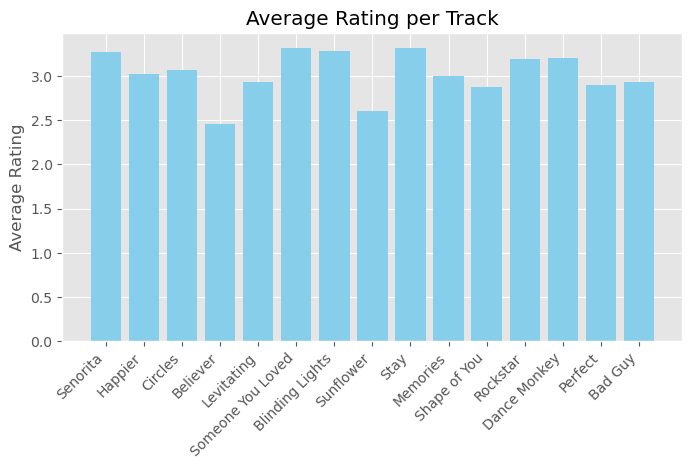

In [31]:
import matplotlib.pyplot as plt

tracks = list(grouped.keys())
ratings = list(grouped.values())

plt.figure(figsize=(8,4))
plt.bar(tracks, ratings, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Average Rating per Track")
plt.ylabel("Average Rating")
plt.show()

---

## Application

In [33]:
target_songs = [
    "Blinding Lights",
    "Dance Monkey",
    "Shape of You",
    "Stay",
    "Bad Guy",
    "Circles",
    "Levitating",
    "Senorita",
    "Someone You Loved",
    "Sunflower",
    "Happier",
    "Memories",
    "Perfect",
    "Rockstar",
    "Believer"
]

In [ ]:
from core import DataFrame

# 1. 準備你的歌單 (這就是你要的順序)
target_songs = [
    "Blinding Lights", "Dance Monkey", "Shape of You", "Stay", 
    "Bad Guy", "Circles", "Levitating", "Senorita", 
    "Someone You Loved", "Sunflower", "Happier", "Memories", 
    "Perfect", "Rockstar", "Believer"
]

# 2. 載入與初步篩選
df = DataFrame.from_csv('../data/spotify_songs.csv')
target_set = set(target_songs) # 轉成 set 加速篩選
filtered_df = df.filter(lambda row: row['track_name'] in target_set)

print(f"篩選後尚未排序: {filtered_df.row_count} 筆")

# =========================================================
# 3. 核心邏輯：依照指定 List 排序 (Custom Sort)
# =========================================================

# (A) 建立優先級對照表: {'Blinding Lights': 0, 'Dance Monkey': 1, ...}
priority_map = {name: i for i, name in enumerate(target_songs)}

# (B) 取得目前資料的所有索引 [0, 1, 2, ... N]
current_indices = range(filtered_df.row_count)

# (C) 進行排序
# key=lambda i: ... 意思是：對於第 i 列資料，去查它的歌名，再查這個歌名在 priority_map 是第幾號
sorted_indices = sorted(
    current_indices, 
    key=lambda i: priority_map.get(filtered_df.data['track_name'][i], 9999)
)

# (D) 根據排好的索引，重新組裝 DataFrame
sorted_data = {
    col: [filtered_df.data[col][i] for i in sorted_indices] 
    for col in filtered_df.columns
}

result_df = DataFrame(sorted_data)

篩選後尚未排序: 113 筆
------------------------------
排序後的結果 (前 15 筆):
['Blinding Lights', 'Blinding Lights', 'Blinding Lights', 'Blinding Lights', 'Blinding Lights', 'Blinding Lights', 'Blinding Lights', 'Blinding Lights', 'Blinding Lights', 'Dance Monkey', 'Dance Monkey', 'Dance Monkey', 'Dance Monkey', 'Dance Monkey', 'Dance Monkey']


In [46]:
grouped_var = result_df.groupby('track_name')
var_stats = grouped_var.aggregate({
    'track_popularity': 'mean'
})

var_stats['track_popularity_mean']

[94.33333333333333,
 71.33333333333333,
 72.75,
 46.0,
 25.0,
 61.714285714285715,
 60.0,
 48.0,
 94.0,
 67.6,
 69.5,
 72.84615384615384,
 54.333333333333336,
 45.666666666666664,
 30.5]

In [ ]:
dict_compare = {'track_name': list(grouped.keys()), 'track_rating_mean': list(grouped.values()), 'track_popularity_mean': list(var_stats['track_popularity_mean'])}
df_new = DataFrame(dict_compare)

track_name        | track_rating_mean  | track_popularity_mean
--------------------------------------------------------------
Senorita          | 3.272727272727273  | 94.33333333333333   
Happier           | 3.0294117647058822 | 71.33333333333333   
Circles           | 3.0689655172413794 | 72.75               
Believer          | 2.4545454545454546 | 46.0                
Levitating        | 2.9361702127659575 | 25.0                
Someone You Loved | 3.317073170731707  | 61.714285714285715  
Blinding Lights   | 3.2903225806451615 | 60.0                
Sunflower         | 2.608695652173913  | 48.0                
Stay              | 3.3225806451612905 | 94.0                
Memories          | 3.0                | 67.6                

... 5 more rows

Shape: (15 rows, 3 columns)

In [58]:
filtered_df = df_new.filter(
    lambda row: (
        row['track_rating_mean'] is not None and row['track_rating_mean'] > 3
        and 
        row['track_popularity_mean'] is not None and row['track_popularity_mean'] < 60
    )
)

# 顯示結果
print(f"篩選完成！符合條件的共有 {filtered_df.row_count} 筆")
print("-" * 30)
print(filtered_df)

篩選完成！符合條件的共有 1 筆
------------------------------
track_name   | track_rating_mean | track_popularity_mean
--------------------------------------------------------
Dance Monkey | 3.2               | 54.333333333333336  

Shape: (1 rows, 3 columns)
